In [6]:
# ==============================================================================
# 0. 导入依赖项
# ==============================================================================
import json, random, time, multiprocessing as mp
import numpy as np
import tensorflow as tf
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.manifold import trustworthiness
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import distance_matrix as sp_dist
import matplotlib.pyplot as plt

print("TF Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TF Version: 2.20.0
GPU Available: []


/workspace/anaconda/envs/py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
# ==============================================================================
# 1. 基础配置与超参数
# ==============================================================================
ASSIGNMENTS = [
    [0,13,31,29, 3, 7, 1,12],
    [30,26,21,25,24, 8,22,15],
    [28, 5,10,14, 6, 2,16,18],
    [19, 4,23,17,20,11, 9,27],
]
ANTENNACOUNT = sum(len(a) for a in ASSIGNMENTS)
TAP_START, TAP_STOP = 507, 520   # 13 taps

N_GEO_K     = 20
TIME_THRESH = 2.0

TEMP        = 0.5    # NT-Xent 温度
LAM_SIAM    = 1.0    # Siamese MDS 权重
LAM_CL      = 0.2    # NT-Xent 投影空间权重
LAM_SINKHORN= 0.08    # Sinkhorn 分布对齐权重
POS_Q       = 0.05
TIME_POS    = 3.0

# 获取全局数据集的大小
N_TOTAL = csi_td.shape[0]

In [8]:
# ==============================================================================
# 2. 数据加载与预处理 (完全兼容 DICHASUS)
# ==============================================================================
def load_dataset(inputpaths, decimation=4):
    def _make_ds(path, offset_path):
        with open(offset_path) as f: offsets = json.load(f)
        def _parse(proto):
            rec = tf.io.parse_single_example(proto,{
                "csi":       tf.io.FixedLenFeature([],tf.string,default_value=""),
                "pos-tachy": tf.io.FixedLenFeature([],tf.string,default_value=""),
                "time":      tf.io.FixedLenFeature([],tf.float32,default_value=0),})
            csi = tf.ensure_shape(tf.io.parse_tensor(rec["csi"],tf.float32),(ANTENNACOUNT,1024,2))
            csi = tf.complex(csi[:,:,0],csi[:,:,1])
            csi = tf.signal.fftshift(csi,axes=1)
            pos = tf.ensure_shape(tf.io.parse_tensor(rec["pos-tachy"],tf.float64),(3,))
            return csi, pos[:2], tf.ensure_shape(rec["time"],())
        def _cal(csi,pos,t):
            n=tf.shape(csi)[1]
            sto=tf.tensordot(tf.constant(offsets["sto"]),
                2*np.pi*tf.range(n,dtype=tf.float32)/tf.cast(n,tf.float32),axes=0)
            cpo=tf.tensordot(tf.constant(offsets["cpo"]),
                tf.ones(n,dtype=tf.float32),axes=0)
            return csi*tf.exp(tf.complex(0.,sto+cpo)),pos,t
        def _ift(csi,pos,t):
            return (tf.signal.fftshift(tf.signal.ifft(tf.signal.fftshift(csi,axes=1)),axes=1),pos,t)
        def _cut(csi,pos,t): return csi[:,TAP_START:TAP_STOP],pos,t
        def _ord(csi,pos,t):
            return tf.stack([tf.gather(csi,idx) for idx in ASSIGNMENTS]),pos,t
        ds = tf.data.TFRecordDataset(path)
        for fn in [_parse,_cal,_ift,_cut,_ord]:
            ds = ds.map(fn, num_parallel_calls=tf.data.AUTOTUNE)
        return ds

    ds = _make_ds(inputpaths[0]["tfrecords"], inputpaths[0]["offsets"])
    for p in inputpaths[1:]:
        ds = ds.concatenate(_make_ds(p["tfrecords"],p["offsets"]))
    ds = ds.shard(decimation, 0)

    csi_l,pos_l,ts_l=[],[],[]
    for csi,pos,ts in ds.batch(1000):
        csi_l.append(csi.numpy()); pos_l.append(pos.numpy()); ts_l.append(ts.numpy())
    return np.concatenate(csi_l), np.concatenate(pos_l), np.concatenate(ts_l)

inputpaths=[
    {"tfrecords":"dichasus/dichasus-cf02.tfrecords", "offsets":"dichasus/reftx-offsets-dichasus-cf02.json"},
    {"tfrecords":"dichasus/dichasus-cf03.tfrecords", "offsets":"dichasus/reftx-offsets-dichasus-cf03.json"},
    {"tfrecords":"dichasus/dichasus-cf04.tfrecords", "offsets":"dichasus/reftx-offsets-dichasus-cf04.json"},
]
print("加载数据中...")
csi_td, gt_pos, timestamps = load_dataset(inputpaths, decimation=4)
B, M, T = csi_td.shape[1], csi_td.shape[2], csi_td.shape[3]
N = csi_td.shape[0]
print(f"Dataset Loaded: N={N:,}  B={B}  M={M}  T={T}")

加载数据中...


2026-03-17 11:33:55.431497: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Dataset Loaded: N=20,997  B=4  M=8  T=13


2026-03-17 11:34:11.021684: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
# ==============================================================================
# 3. 预先计算真值距离图 (ADP & Geodesic)
# ==============================================================================
def _adp_worker(todo_q, out_q, csi):
    while True:
        i = todo_q.get()
        if i == -1: out_q.put((-1,None)); return
        h   = csi[i]; w = csi[i:]
        dot = np.abs(np.einsum("bmt,lbmt->lbt",np.conj(h),w,optimize=True))**2
        n_h = np.real(np.einsum("bmt,bmt->bt",h,np.conj(h),optimize=True))
        n_w = np.real(np.einsum("lbmt,lbmt->lbt",w,np.conj(w),optimize=True))
        row = np.sum(1 - dot/(n_h[None]*n_w+1e-10), axis=(1,2))
        out_q.put((i, row.astype(np.float32)))

def compute_adp(csi):
    N_=csi.shape[0]; D=np.zeros((N_,N_),dtype=np.float32)
    tq,oq=mp.Queue(),mp.Queue()
    for i in range(N_): tq.put(i)
    for _ in range(mp.cpu_count()): tq.put(-1)
    [mp.Process(target=_adp_worker,args=(tq,oq,csi)).start() for _ in range(mp.cpu_count())]
    done,pbar=0,tqdm(total=N_*N_,desc="ADP")
    while done<mp.cpu_count():
        i,row=oq.get()
        if i==-1: done+=1
        else:
            D[i,i:]=row; D[i:,i]=row
            pbar.update(2*len(row)-1)
    pbar.close()
    return D

d_adp = compute_adp(csi_td)
d_time = np.abs(np.subtract.outer(timestamps, timestamps)).astype(np.float32)

mask = (d_time < TIME_THRESH) & (d_time > 0)
ratios = d_adp[mask] / d_time[mask]
occ, edges = np.histogram(ratios, bins=1500, range=(0,50))
centers = edges[:-1]+np.diff(edges)/2
peak = np.argmax(occ)
thr = np.quantile(occ[:peak+1], 0.5)
gamma = float(centers[next((b for b in range(peak-1,-1,-1) if occ[b]<thr), 0)])
d_fused = np.minimum(d_adp, gamma * d_time)

def compute_geodesic(D, k=N_GEO_K):
    nbrs = NearestNeighbors(n_neighbors=k,metric="precomputed",n_jobs=-1).fit(D)
    graph = kneighbors_graph(nbrs,k,metric="precomputed",mode="distance")
    Dg = np.zeros((N,N),dtype=np.float32)
    for i in tqdm(range(N), desc="Geodesic"):
        Dg[i] = dijkstra(graph,directed=False,indices=i).astype(np.float32)
    fin_max = Dg[np.isfinite(Dg)].max()*2
    Dg = np.where(np.isinf(Dg),fin_max,Dg)
    return Dg

d_geo = compute_geodesic(d_fused)


Geodesic: 100%|██████████| 20997/20997 [06:08<00:00, 56.96it/s]


In [16]:
# ==============================================================================
# 2. 模型架构定义
# ==============================================================================
class TransformerFeatureLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim=64, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.dense_proj = tf.keras.layers.Dense(embed_dim)
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(embed_dim * 2, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.flatten = tf.keras.layers.Flatten()

    def call(self, inputs):
        x = tf.stack([tf.math.real(inputs), tf.math.imag(inputs)], axis=-1)
        batch_size = tf.shape(x)[0]
        # B * M 视为序列长度, T * 2 视为特征维
        seq_len = x.shape[1] * x.shape[2]
        feat_dim = x.shape[3] * x.shape[4]
        x = tf.reshape(x, [batch_size, seq_len, feat_dim])
        
        x = self.dense_proj(x)
        attn_out = self.mha(x, x)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return self.flatten(x)

def build_model():
    csi_in = tf.keras.Input(shape=(B,M,T), dtype=tf.complex64, name='csi')
    feat = TransformerFeatureLayer(embed_dim=64, num_heads=4)(csi_in)
    
    x = tf.keras.layers.Dense(512, activation='relu')(feat)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    coords = tf.keras.layers.Dense(2, activation='linear', name='coords')(x)
    
    proj = tf.keras.layers.Dense(128, activation='gelu', name='proj_hidden')(x)
    proj = tf.keras.layers.Dense(64,  activation='linear', name='proj_out')(proj)
    proj_norm = tf.keras.layers.Lambda(lambda z: tf.nn.l2_normalize(z, axis=1))(proj)

    model_train = tf.keras.Model(inputs=csi_in, outputs=[coords, proj_norm])
    model_infer = tf.keras.Model(inputs=csi_in, outputs=coords)
    return model_train, model_infer


In [17]:

# ==============================================================================
# 3. 损失函数
# ==============================================================================
dissim_margin = float(np.quantile(d_geo[d_geo > 0], 0.01))

@tf.function
def siamese_loss(d_true, coords_pred):
    d_true = tf.reshape(d_true, (-1,))
    zA, zB = coords_pred[:, :2], coords_pred[:, 2:]
    d_pred = tf.norm(zA - zB, axis=1)
    return tf.reduce_mean(tf.square(d_pred - d_true) / (d_true + dissim_margin))

@tf.function
def nt_xent_loss(pA, pB, temperature=TEMP, tw=None):
    N_ = tf.shape(pA)[0]
    z = tf.concat([pA, pB], axis=0)
    sim = tf.matmul(z, tf.transpose(z)) / temperature
    mask = 1.0 - tf.eye(2 * N_)
    sim = sim * mask - 1e9 * (1.0 - mask)
    lbl = tf.concat([tf.range(N_, 2*N_), tf.range(0, N_)], axis=0)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(lbl, sim)
    if tw is not None:
        w = tf.concat([tw, tw], axis=0)
        w = w / (tf.reduce_mean(w) + 1e-8)
        loss = loss * w
    return tf.reduce_mean(loss)

@tf.function
def sinkhorn_loss(pA, pB, epsilon=0.1, n_iters=5):
    batch_size = tf.shape(pA)[0]
    pA_sq = tf.reduce_sum(tf.square(pA), axis=1, keepdims=True)
    pB_sq = tf.reduce_sum(tf.square(pB), axis=1, keepdims=True)
    C = pA_sq + tf.transpose(pB_sq) - 2.0 * tf.matmul(pA, tf.transpose(pB))
    K = tf.exp(-C / epsilon)
    u = tf.ones((batch_size, 1)) / tf.cast(batch_size, tf.float32)
    v = tf.ones((batch_size, 1)) / tf.cast(batch_size, tf.float32)
    for _ in range(n_iters):
        u = 1.0 / (tf.matmul(K, v) + 1e-8)
        v = 1.0 / (tf.matmul(tf.transpose(K), u) + 1e-8)
    P = u * K * tf.transpose(v)
    return tf.reduce_sum(P * C)

def build_pos_pairs(d_geo_sub, timestamps_sub, geo_q=0.05, time_thresh=3.0):
    N_sub = d_geo_sub.shape[0]
    geo_thresh = np.quantile(d_geo_sub[d_geo_sub > 0], geo_q)
    td = np.abs(np.subtract.outer(timestamps_sub, timestamps_sub))
    mask = ((d_geo_sub < geo_thresh) | (td < time_thresh)) & ~np.eye(N_sub, dtype=bool) & np.triu(np.ones((N_sub, N_sub), dtype=bool), k=1)
    r, c = np.where(mask)
    return np.stack([r, c], axis=1).astype(np.int32)

def affine_align(src, tgt):
    if np.std(src) < 1e-6: return src
    pad = lambda x: np.hstack([x, np.ones((len(x),1))])
    try:
        A,*_ = np.linalg.lstsq(pad(src), pad(tgt), rcond=None)
        return (pad(src)@A)[:,:2]
    except np.linalg.LinAlgError:
        return src + (tgt.mean(0) - src.mean(0))

In [ ]:
# ==============================================================================
# 4. 封装训练与评估流程 (支持任意数据比例)
# ==============================================================================
def train_and_evaluate(fraction):
    print(f"\n{'='*50}\n开始训练 - 数据比例: {fraction*100}% \n{'='*50}")
    N_sub = int(N_TOTAL * fraction)
    
    # 随机采样数据子集
    indices = np.random.choice(N_TOTAL, N_sub, replace=False)
    csi_sub = csi_td[indices]
    timestamps_sub = timestamps[indices]
    
    # 从预计算的全局 d_geo 中切片（加速计算）
    d_geo_sub = d_geo[indices][:, indices]
    pos_pairs_sub = build_pos_pairs(d_geo_sub, timestamps_sub)
    
    # 构建新模型与优化器
    model_train, model_infer = build_model()
    optimizer = tf.keras.optimizers.Adam()
    
    inp_a = tf.keras.Input(shape=(B,M,T), dtype=tf.complex64)
    inp_b = tf.keras.Input(shape=(B,M,T), dtype=tf.complex64)
    co_a, _ = model_train(inp_a)
    co_b, _ = model_train(inp_b)
    siamese = tf.keras.Model([inp_a, inp_b], tf.keras.layers.Concatenate(axis=1)([co_a, co_b]))

    csi_t = tf.constant(csi_sub)
    dg_t = tf.constant(d_geo_sub)
    
    # 延长训练步数以保证 Transformer 收敛
    sessions = [
        dict(lr=5e-3, bs=1000, cl_bs=256, steps=800),
        dict(lr=1e-3, bs=2000, cl_bs=512, steps=600),
        dict(lr=3e-4, bs=4000, cl_bs=512, steps=400),
    ]
    
    @tf.function
    def train_step(ca, cb, dt, ca_cl, cb_cl, tw):
        with tf.GradientTape() as tape:
            pred = siamese([ca, cb], training=True)
            l_s = siamese_loss(dt, pred)
            
            _, pA = model_train(ca_cl, training=True)
            _, pB = model_train(cb_cl, training=True)
            l_cl = nt_xent_loss(pA, pB, tw=tw)
            l_sh = sinkhorn_loss(pA, pB)
            
            loss = LAM_SIAM * l_s + LAM_CL * l_cl + LAM_SINKHORN * l_sh
        grads = tape.gradient(loss, model_train.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_train.trainable_variables))
        return loss

    # 训练循环
    for s_idx, sess in enumerate(sessions):
        lr = sess['lr']
        # 针对小样本集自动限制 batch_size
        bs = min(sess['bs'], N_sub)
        cl_bs = min(sess['cl_bs'], len(pos_pairs_sub)) if len(pos_pairs_sub) > 0 else 2
        steps = sess['steps']
        optimizer.learning_rate.assign(lr)
        
        pbar = tqdm(range(steps), desc=f"Session {s_idx+1}/{len(sessions)}")
        for step in pbar:
            ia = tf.random.uniform((bs,), 0, N_sub, dtype=tf.int32)
            ib = tf.random.uniform((bs,), 0, N_sub, dtype=tf.int32)
            ca, cb = tf.gather(csi_t, ia), tf.gather(csi_t, ib)
            dt = tf.gather_nd(dg_t, tf.stack([ia, ib], axis=1))

            if len(pos_pairs_sub) > cl_bs:
                sel = pos_pairs_sub[np.random.choice(len(pos_pairs_sub), cl_bs, replace=False)]
                ca_cl, cb_cl = tf.gather(csi_t, sel[:,0]), tf.gather(csi_t, sel[:,1])
                tdiff = np.abs(timestamps_sub[sel[:,0]] - timestamps_sub[sel[:,1]])
                tw = tf.constant(np.exp(-tdiff / 5.).astype(np.float32))
            else:
                ca_cl, cb_cl = ca[:cl_bs], cb[:cl_bs]
                tw = tf.ones((cl_bs,))

            loss = train_step(ca, cb, dt, ca_cl, cb_cl, tw)
            if step % 100 == 0:
                pbar.set_postfix({"Loss": float(loss)})

    # ================= 评估 (在全量全局数据集上进行泛化测试) =================
    print(f"评估 {fraction*100}% 模型在全量数据上的泛化能力...")
    chart_all = model_infer.predict(csi_td, batch_size=512, verbose=0)
    chart_aligned = affine_align(chart_all, gt_pos)
    
    # MAE 计算
    errors = np.linalg.norm(gt_pos - chart_aligned, axis=1)
    mae = float(np.mean(errors))
    
    # 计算流形保留指标 (随机采 20% 全局点加速评测)
    eval_sub = random.sample(range(N_TOTAL), N_TOTAL // 5)
    gt_s, ch_s = gt_pos[eval_sub], chart_all[eval_sub]
    K = int(0.05 * len(eval_sub))
    tw_ = trustworthiness(gt_s, ch_s, n_neighbors=K)
    ct_ = trustworthiness(ch_s, gt_s, n_neighbors=K)
    
    dX = sp_dist(gt_s, gt_s); dZ = sp_dist(ch_s, ch_s)
    beta = (dX*dZ).sum() / ((dZ*dZ).sum()+1e-9)
    ks_ = float(np.sqrt(((dX-beta*dZ)**2).sum() / ((dX*dX).sum()+1e-9)))

    print(f"[{fraction*100}% Data] CT: {ct_:.4f} | TW: {tw_:.4f} | KS: {ks_:.4f} | MAE: {mae:.4f}m")
    return {'fraction': fraction, 'CT': ct_, 'TW': tw_, 'KS': ks_, 'MAE': mae, 'chart': chart_aligned}



In [19]:
# ==============================================================================
# 5. 执行多数据比例对比实验
# ==============================================================================
fractions = [1.0, 0.5, 0.1, 0.05, 0.01]
results = []

for frac in fractions:
    res = train_and_evaluate(frac)
    results.append(res)


开始训练 - 数据比例: 100.0% 


Session 3/3: 100%|██████████| 400/400 [05:56<00:00,  1.12it/s, Loss=4.77]


评估 100.0% 模型在全量数据上的泛化能力...
[100.0% Data] CT: 0.9934 | TW: 0.9934 | KS: 0.0958 | MAE: 0.4631m

开始训练 - 数据比例: 50.0% 


Session 3/3: 100%|██████████| 400/400 [04:41<00:00,  1.42it/s, Loss=4.82]


评估 50.0% 模型在全量数据上的泛化能力...
[50.0% Data] CT: 0.9893 | TW: 0.9897 | KS: 0.1092 | MAE: 0.5166m

开始训练 - 数据比例: 10.0% 


...

评估 10.0% 模型在全量数据上的泛化能力...
[10.0% Data] CT: 0.9784 | TW: 0.9774 | KS: 0.1340 | MAE: 0.6744m

开始训练 - 数据比例: 5.0% 


Session 3/3: 100%|██████████| 400/400 [01:19<00:00,  5.03it/s, Loss=4.42]


评估 5.0% 模型在全量数据上的泛化能力...
[5.0% Data] CT: 0.9578 | TW: 0.9567 | KS: 0.1639 | MAE: 0.8666m

开始训练 - 数据比例: 1.0% 


Session 3/3: 100%|██████████| 400/400 [00:34<00:00, 11.70it/s, Loss=4.49]


评估 1.0% 模型在全量数据上的泛化能力...
[1.0% Data] CT: 0.8705 | TW: 0.8526 | KS: 0.2948 | MAE: 1.5962m


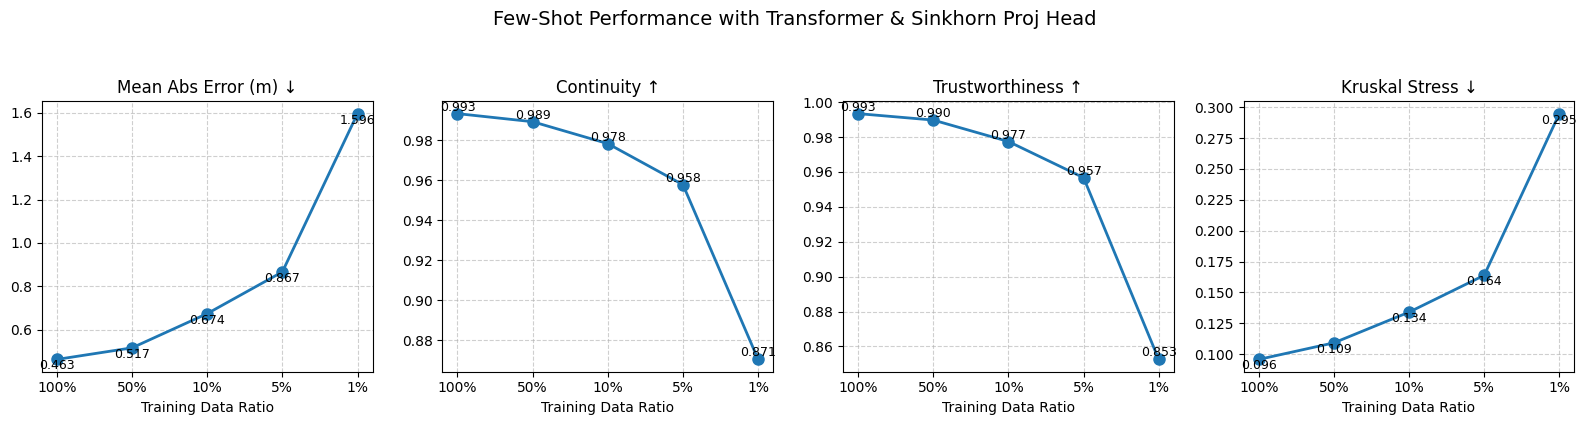

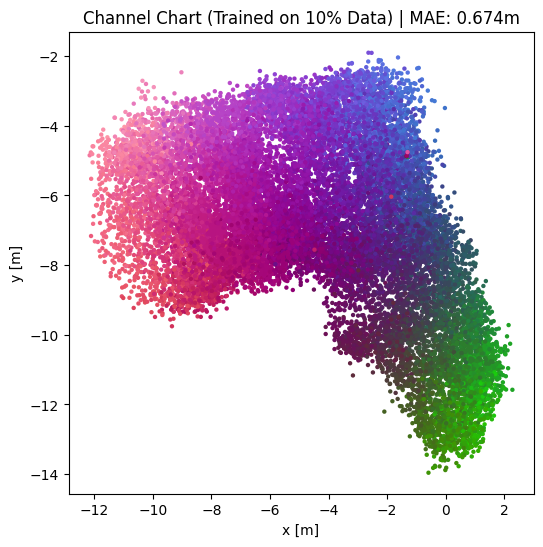

In [20]:
# ==============================================================================
# 6. 可视化对比结果
# ==============================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
x_labels = [f"{int(r['fraction']*100)}%" for r in results]
x_pos = np.arange(len(fractions))

metrics = [
    ('MAE', 'Mean Abs Error (m) ↓', [r['MAE'] for r in results]),
    ('CT', 'Continuity ↑', [r['CT'] for r in results]),
    ('TW', 'Trustworthiness ↑', [r['TW'] for r in results]),
    ('KS', 'Kruskal Stress ↓', [r['KS'] for r in results])
]

for idx, (m_name, m_title, vals) in enumerate(metrics):
    ax = axes[idx]
    ax.plot(x_pos, vals, marker='o', linestyle='-', color='tab:blue', linewidth=2, markersize=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_title(m_title, fontsize=12)
    ax.set_xlabel("Training Data Ratio", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # 标注具体数值
    for i, v in enumerate(vals):
        ax.text(x_pos[i], v, f"{v:.3f}", ha='center', va='bottom' if idx in [1,2] else 'top', fontsize=9)

plt.suptitle("Few-Shot Performance with Transformer & Sinkhorn Proj Head", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# 绘制 10% 极少数据情况下的生成流形 (Channel Chart)
res_10 = next(r for r in results if r['fraction'] == 0.1)
cx=0.5*(gt_pos[:,0].min()+gt_pos[:,0].max()); cy=0.5*(gt_pos[:,1].min()+gt_pos[:,1].max())
nrm=lambda x:(x-x.min())/(x.max()-x.min()+1e-9)
rgb=np.zeros((len(gt_pos),3))
rgb[:,0]=1-0.9*nrm(gt_pos[:,0])
rgb[:,1]=0.8*nrm(np.linalg.norm(gt_pos-[cx,cy],axis=1)**2)
rgb[:,2]=0.9*nrm(gt_pos[:,1])

plt.figure(figsize=(6,6))
plt.title(f"Channel Chart (Trained on 10% Data) | MAE: {res_10['MAE']:.3f}m")
plt.scatter(res_10['chart'][:,0], res_10['chart'][:,1], c=rgb, alpha=1., s=10, linewidths=0)
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.show()

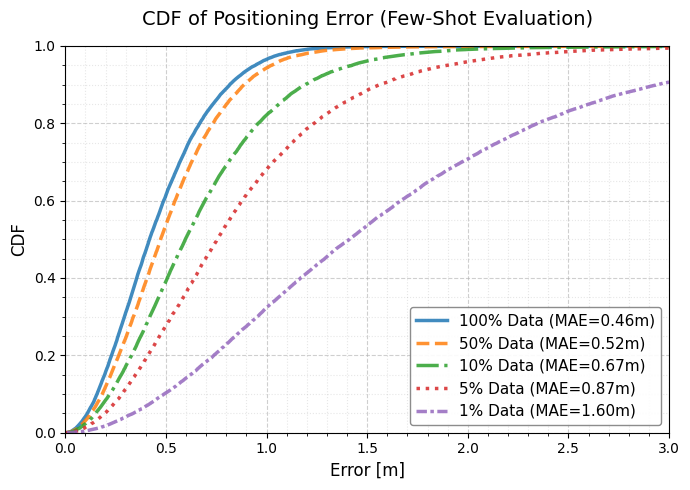

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 绘制少样本对比的 CDF (Cumulative Distribution Function) 曲线
# ==============================================================================

plt.figure(figsize=(7, 5))

# 定义高级感配色和不同的线型，确保在单色打印或视觉区分度上表现良好
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 遍历我们之前保存的不同数据比例的结果
for idx, res in enumerate(results):
    frac = res['fraction']
    chart_aligned = res['chart']
    mae = res['MAE']
    
    # 重新计算该组数据的每一个点的绝对位置误差
    errors = np.linalg.norm(gt_pos - chart_aligned, axis=1)
    
    # 将误差从小到大排序，生成 CDF 的 x 轴
    sorted_errors = np.sort(errors)
    
    # 生成对应的累积概率，作为 CDF 的 y 轴 (0 到 1)
    y_vals = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    
    # 设置图例标签，包含数据比例和对应的 MAE
    label_str = f"{int(frac * 100)}% Data (MAE={mae:.2f}m)"
    
    # 绘制阶梯状/平滑曲线
    plt.plot(sorted_errors, y_vals, 
             linestyle=line_styles[idx % len(line_styles)], 
             color=colors[idx % len(colors)], 
             linewidth=2.5, 
             alpha=0.85, 
             label=label_str)

# ── 图表细节打磨 (参考上传图像的专业风格) ──
plt.xlim(0, 3.0)     # 设置 X 轴范围，通常 Channel Charting 关注 3 米以内的误差
plt.ylim(0, 1.0)     # CDF 的 Y 轴固定在 0 到 1

plt.xlabel('Error [m]', fontsize=12, fontweight='medium')
plt.ylabel('CDF', fontsize=12, fontweight='medium')
plt.title('CDF of Positioning Error (Few-Shot Evaluation)', fontsize=14, pad=15)

# 开启网格线，更利于读取具体区间的百分比
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)
plt.minorticks_on()

# 将图例放在右下角，避免遮挡左上角快速攀升的曲线
plt.legend(loc='lower right', fontsize=11, framealpha=0.9, edgecolor='gray')

plt.tight_layout()

# 如需保存高清图片用于论文或答辩汇报，可取消下方注释
# plt.savefig("cdf_few_shot_transformer.png", dpi=300, bbox_inches='tight')

plt.show()


开始 NLoS 场景评估 (模拟金属集装箱遮挡)
NLoS Dataset Shape: (20997, 2, 8, 13)
计算 NLoS 下的 ADP 矩阵...


ADP: 100%|██████████| 440874009/440874009 [00:05<00:00, 80041790.39it/s]


计算 NLoS 下的 Geodesic 矩阵...


NLoS Session 2: 100%|██████████| 600/600 [04:57<00:00,  2.02it/s, Loss=4.17]



[NLoS Data] CT: 0.9440 | TW: 0.9283 | KS: 0.2256 | MAE: 1.2737m


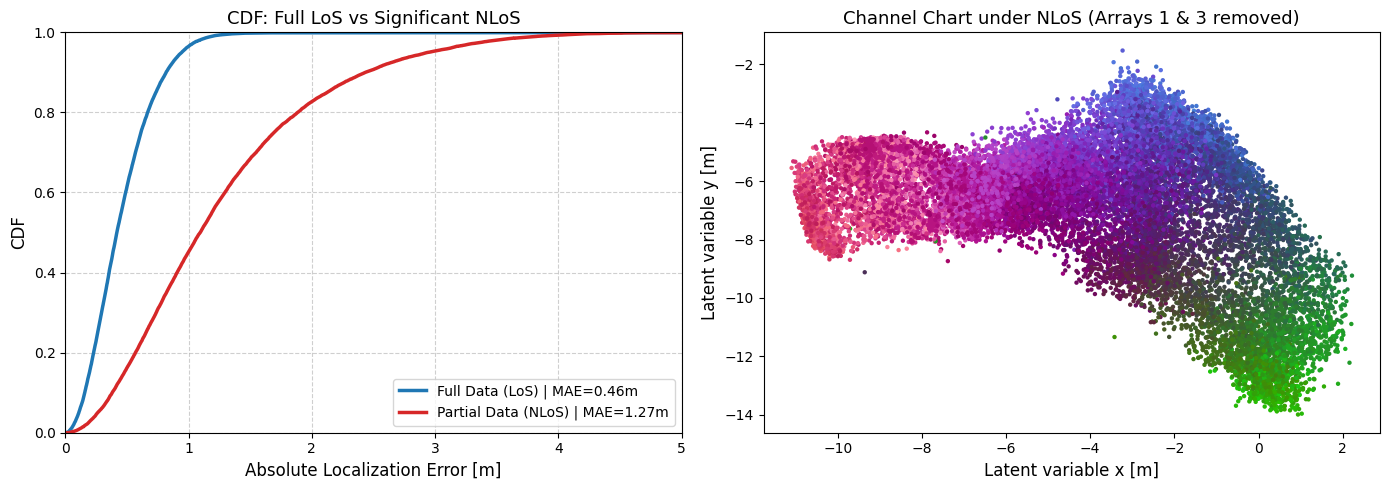

In [22]:
# ==============================================================================
# 补充实验：NLoS (非视距) 场景下的 Channel Charting 表现
# 策略：移除 b=2 和 b=4 (Python 索引为 1 和 3) 的天线阵列数据模拟金属遮挡
# ==============================================================================
import copy

print(f"\n{'='*50}\n开始 NLoS 场景评估 (模拟金属集装箱遮挡)\n{'='*50}")

# 1. 构建 NLoS 数据集 (移除阵列 1 和 3)
# 原始 csi_td shape: (N, 4, M, T) -> 新的 shape: (N, 2, M, T)
csi_nlos = csi_td[:, [0, 2], :, :]
B_nlos = csi_nlos.shape[1]
print(f"NLoS Dataset Shape: {csi_nlos.shape}")

# 2. 重新计算 NLoS 环境下的伪标签 (ADP & 测地线)
# 因为基站少了两个，自相关距离矩阵必须重新计算
print("计算 NLoS 下的 ADP 矩阵...")
d_adp_nlos = compute_adp(csi_nlos)

# 重新拟合 NLoS 下的时间-距离融合系数 gamma
ratios_nlos = d_adp_nlos[mask] / d_time[mask]
occ_n, edges_n = np.histogram(ratios_nlos, bins=1500, range=(0,50))
centers_n = edges_n[:-1] + np.diff(edges_n)/2
peak_n = np.argmax(occ_n)
thr_n = np.quantile(occ_n[:peak_n+1], 0.5)
gamma_nlos = float(centers_n[next((b for b in range(peak_n-1,-1,-1) if occ_n[b]<thr_n), 0)])

d_fused_nlos = np.minimum(d_adp_nlos, gamma_nlos * d_time)

# 重新计算 NLoS 最短路径流形
print("计算 NLoS 下的 Geodesic 矩阵...")
d_geo_nlos = compute_geodesic(d_fused_nlos)

# 重构正样本对
pos_pairs_nlos = build_pos_pairs(d_geo_nlos, timestamps)

# 3. 构建适应 B=2 的新模型
def build_nlos_model():
    csi_in = tf.keras.Input(shape=(B_nlos, M, T), dtype=tf.complex64)
    feat = TransformerFeatureLayer(embed_dim=64, num_heads=4)(csi_in)
    
    x = tf.keras.layers.Dense(512, activation='relu')(feat)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    coords = tf.keras.layers.Dense(2, activation='linear', name='coords')(x)
    
    proj = tf.keras.layers.Dense(128, activation='gelu')(x)
    proj = tf.keras.layers.Dense(64, activation='linear')(proj)
    proj_norm = tf.keras.layers.Lambda(lambda z: tf.nn.l2_normalize(z, axis=1))(proj)

    return tf.keras.Model(inputs=csi_in, outputs=[coords, proj_norm]), tf.keras.Model(inputs=csi_in, outputs=coords)

model_train_nlos, model_infer_nlos = build_nlos_model()

# 4. 训练 NLoS 模型
inp_a = tf.keras.Input(shape=(B_nlos, M, T), dtype=tf.complex64)
inp_b = tf.keras.Input(shape=(B_nlos, M, T), dtype=tf.complex64)
co_a, _ = model_train_nlos(inp_a)
co_b, _ = model_train_nlos(inp_b)
siamese_nlos = tf.keras.Model([inp_a, inp_b], tf.keras.layers.Concatenate(axis=1)([co_a, co_b]))

optimizer_nlos = tf.keras.optimizers.Adam()
csi_t_nlos = tf.constant(csi_nlos)
dg_t_nlos = tf.constant(d_geo_nlos)

# 由于环境变复杂，我们给予适中的训练步数
sessions_nlos = [
    dict(lr=5e-3, bs=1000, cl_bs=256, steps=800),
    dict(lr=1e-3, bs=2000, cl_bs=512, steps=600),
]

@tf.function
def train_step_nlos(ca, cb, dt, ca_cl, cb_cl, tw):
    with tf.GradientTape() as tape:
        pred = siamese_nlos([ca, cb], training=True)
        l_s = siamese_loss(dt, pred)
        
        _, pA = model_train_nlos(ca_cl, training=True)
        _, pB = model_train_nlos(cb_cl, training=True)
        l_cl = nt_xent_loss(pA, pB, tw=tw)
        l_sh = sinkhorn_loss(pA, pB)
        
        # 使用相同的损失权重设置
        loss = LAM_SIAM * l_s + LAM_CL * l_cl + LAM_SINKHORN * l_sh
    grads = tape.gradient(loss, model_train_nlos.trainable_variables)
    optimizer_nlos.apply_gradients(zip(grads, model_train_nlos.trainable_variables))
    return loss

for s_idx, sess in enumerate(sessions_nlos):
    optimizer_nlos.learning_rate.assign(sess['lr'])
    pbar = tqdm(range(sess['steps']), desc=f"NLoS Session {s_idx+1}")
    for step in pbar:
        ia = tf.random.uniform((sess['bs'],), 0, N, dtype=tf.int32)
        ib = tf.random.uniform((sess['bs'],), 0, N, dtype=tf.int32)
        ca, cb = tf.gather(csi_t_nlos, ia), tf.gather(csi_t_nlos, ib)
        dt = tf.gather_nd(dg_t_nlos, tf.stack([ia, ib], axis=1))

        sel = pos_pairs_nlos[np.random.choice(len(pos_pairs_nlos), sess['cl_bs'], replace=False)]
        ca_cl, cb_cl = tf.gather(csi_t_nlos, sel[:,0]), tf.gather(csi_t_nlos, sel[:,1])
        tdiff = np.abs(timestamps[sel[:,0]] - timestamps[sel[:,1]])
        tw = tf.constant(np.exp(-tdiff / 5.).astype(np.float32))

        loss = train_step_nlos(ca, cb, dt, ca_cl, cb_cl, tw)
        if step % 100 == 0:
            pbar.set_postfix({"Loss": float(loss)})

# 5. NLoS 结果评估与对齐
chart_nlos = model_infer_nlos.predict(csi_nlos, batch_size=512, verbose=0)
chart_nlos_aligned = affine_align(chart_nlos, gt_pos)

errors_nlos = np.linalg.norm(gt_pos - chart_nlos_aligned, axis=1)
mae_nlos = float(np.mean(errors_nlos))

eval_sub = random.sample(range(N), N // 5)
gt_s, ch_s = gt_pos[eval_sub], chart_nlos_aligned[eval_sub]
K = int(0.05 * len(eval_sub))

ct_nlos = trustworthiness(ch_s, gt_s, n_neighbors=K)
tw_nlos = trustworthiness(gt_s, ch_s, n_neighbors=K)

dX = sp_dist(gt_s, gt_s); dZ = sp_dist(ch_s, ch_s)
beta = (dX*dZ).sum() / ((dZ*dZ).sum()+1e-9)
ks_nlos = float(np.sqrt(((dX-beta*dZ)**2).sum() / ((dX*dX).sum()+1e-9)))

print(f"\n[NLoS Data] CT: {ct_nlos:.4f} | TW: {tw_nlos:.4f} | KS: {ks_nlos:.4f} | MAE: {mae_nlos:.4f}m")

# ==============================================================================
# 6. NLoS vs Full LoS 累计误差分布 (CDF) 及流形图对比绘制
# ==============================================================================
# 提取全量数据模型的误差 (前面代码跑完存留在内存中的 results 第一项)
res_full = next(r for r in results if r['fraction'] == 1.0)
errors_full = np.linalg.norm(gt_pos - res_full['chart'], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- 子图 1: CDF 曲线对比 ---
for errs, label, color in [(errors_full, f'Full Data (LoS) | MAE={res_full["MAE"]:.2f}m', '#1f77b4'), 
                           (errors_nlos, f'Partial Data (NLoS) | MAE={mae_nlos:.2f}m', '#d62728')]:
    sorted_errs = np.sort(errs)
    y_vals = np.arange(1, len(sorted_errs) + 1) / len(sorted_errs)
    ax1.plot(sorted_errs, y_vals, label=label, color=color, linewidth=2.5)

ax1.set_xlim(0, 5.0)  # NLoS 误差较大，X轴放宽到 5 米
ax1.set_ylim(0, 1.0)
ax1.set_xlabel('Absolute Localization Error [m]', fontsize=12)
ax1.set_ylabel('CDF', fontsize=12)
ax1.set_title('CDF: Full LoS vs Significant NLoS', fontsize=13)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 子图 2: NLoS 降维流形可视化 ---
cx=0.5*(gt_pos[:,0].min()+gt_pos[:,0].max()); cy=0.5*(gt_pos[:,1].min()+gt_pos[:,1].max())
nrm=lambda x:(x-x.min())/(x.max()-x.min()+1e-9)
rgb=np.zeros((len(gt_pos),3))
rgb[:,0]=1-0.9*nrm(gt_pos[:,0])
rgb[:,1]=0.8*nrm(np.linalg.norm(gt_pos-[cx,cy],axis=1)**2)
rgb[:,2]=0.9*nrm(gt_pos[:,1])

ax2.scatter(chart_nlos_aligned[:,0], chart_nlos_aligned[:,1], c=rgb, alpha=1., s=10, linewidths=0)
ax2.set_xlabel('Latent variable x [m]', fontsize=12)
ax2.set_ylabel('Latent variable y [m]', fontsize=12)
ax2.set_title('Channel Chart under NLoS (Arrays 1 & 3 removed)', fontsize=13)

plt.tight_layout()
plt.show()